In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("Titanic Dataset.csv")
data.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [21]:
# Check Missing Values
data.isnull().sum()

pclass        0
survived      0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked_Q    0
embarked_S    0
dtype: int64

In [22]:
print(data.columns)

Index(['pclass', 'survived', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked_Q', 'embarked_S'],
      dtype='object')


In [34]:
data['FamilySize'] = data['sibsp'] + data['parch'] + 1

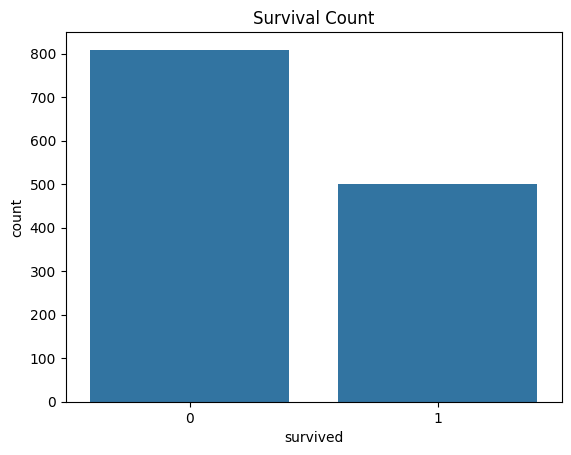

In [ ]:
# Survival Count
sns.countplot(x='survived', data=data)
plt.title("Survival Count")
plt.show()

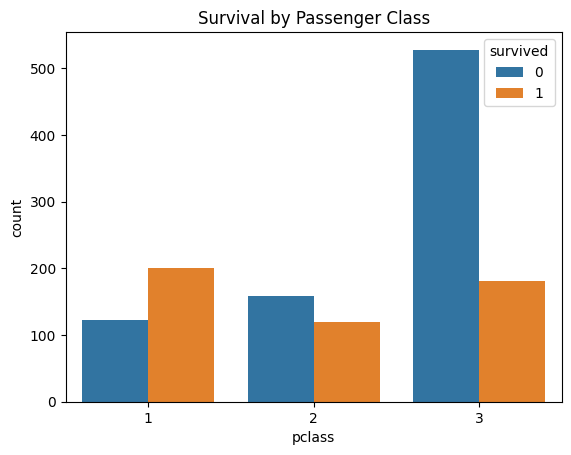

In [ ]:
# Survival by Passenger Class
sns.countplot(x='pclass', hue='survived', data=data)
plt.title("Survival by Passenger Class")
plt.show()

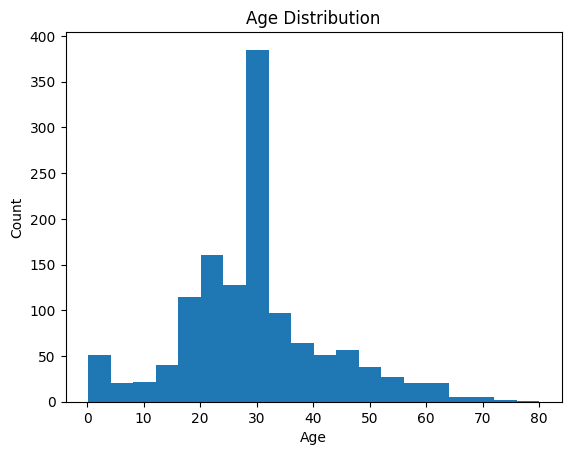

In [25]:
# Age Distribution
plt.hist(data['age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [36]:
X = data[['pclass','sex','age','fare','FamilySize','embarked_Q','embarked_S']]
y = data['survived']

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [38]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
y_pred = model.predict(X_test)

In [40]:
from sklearn.metrics import accuracy_score

print("Accuracy:", round(accuracy_score(y_test, y_pred)*100,2), "%")

Accuracy: 77.48 %


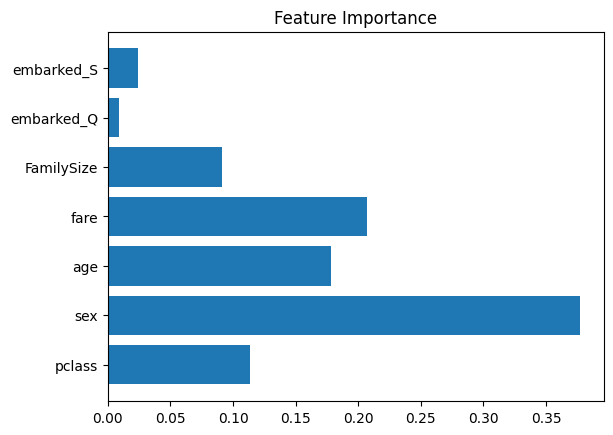

In [41]:
importance = model.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()